In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds


Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.
Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


540/540 - 27s - 50ms/step - accuracy: 0.9098 - loss: 0.3034 - val_accuracy: 0.9737 - val_loss: 0.0940
Epoch 2/15
540/540 - 20s - 37ms/step - accuracy: 0.9742 - loss: 0.0845 - val_accuracy: 0.9777 - val_loss: 0.0661
Epoch 3/15
540/540 - 22s - 41ms/step - accuracy: 0.9819 - loss: 0.0584 - val_accuracy: 0.9840 - val_loss: 0.0476
Epoch 4/15
540/540 - 20s - 38ms/step - accuracy: 0.9853 - loss: 0.0465 - val_accuracy: 0.9840 - val_loss: 0.0464
Epoch 5/15
540/540 - 22s - 41ms/step - accuracy: 0.9881 - loss: 0.0384 - val_accuracy: 0.9887 - val_loss: 0.0346
Epoch 6/15
540/540 - 41s - 76ms/step - accuracy: 0.9899 - loss: 0.0321 - val_accuracy: 0.9892 - val_loss: 0.0330
Epoch 7/15
540/540 - 42s - 77ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9888 - val_loss: 0.0349
Epoch 8/15
540/540 - 20s - 37ms/step - accuracy: 0.9913 - loss: 0.0255 - val_accuracy: 0.9927 - val_loss: 0.0230
Epoch 9/15
540/540 - 21s - 40ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9917 - val_loss: 0

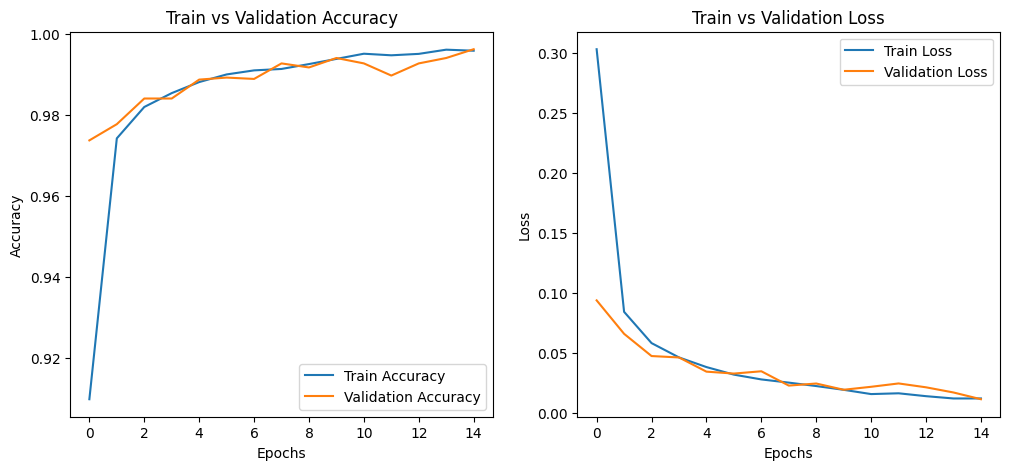

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


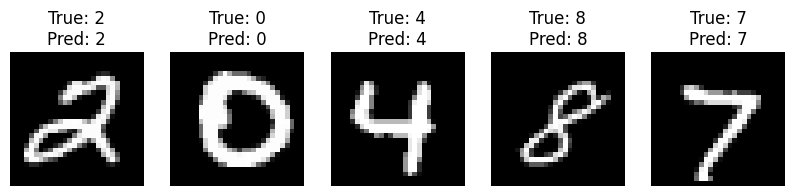

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Load MNIST dataset
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Split dataset into training and validation sets
num_validation_samples = tf.cast(0.1 * mnist_info.splits['train'].num_examples, tf.int64)
num_test_samples = tf.cast(mnist_info.splits['test'].num_examples, tf.int64)

# Function to normalize image data
def scale(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply scaling
scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

# Shuffle and split into train and validation
BUFFER_SIZE = 10000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

# Define batch size
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

# Extract validation inputs and targets
validation_inputs, validation_targets = next(iter(validation_data))

# Define CNN model with 28x28 input size
model = tf.keras.Sequential([
    # Input Layer: (28,28,1) (Grayscale, so only 1 channel)
    tf.keras.layers.Conv2D(filters=8, kernel_size=(5, 5), strides=1, padding='valid', activation='relu', input_shape=(28, 28, 1)),

    # POOL1: (24,24,8) → (12,12,8) [MaxPooling 2x2]
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # CONV2: (12,12,8) → (8,8,16) [Filter 5x5, Stride 1]
    tf.keras.layers.Conv2D(filters=16, kernel_size=(5, 5), strides=1, padding='valid', activation='relu'),

    # POOL2: (8,8,16) → (4,4,16) [MaxPooling 2x2]
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Flattening (4,4,16) → 256
    tf.keras.layers.Flatten(),

    # FC3: (256) → (120)
    tf.keras.layers.Dense(120, activation='relu'),

    # FC4: (120) → (84)
    tf.keras.layers.Dense(84, activation='relu'),

    # Softmax: (84) → (10) (Final Output Layer)
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
NUM_EPOCHS = 15
history = model.fit(train_data, epochs=NUM_EPOCHS, validation_data=(validation_inputs, validation_targets), verbose=2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy:.4f}")

# PLOT TRAINING & VALIDATION ACCURACY AND LOSS
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Validation Loss')

plt.show()

# PREDICTING & DISPLAYING IMAGES WITH TRUE AND PREDICTED LABELS
def display_predictions(model, dataset, num_images=5):
    test_images, test_labels = next(iter(dataset))  # Get a batch of test images
    predictions = model.predict(test_images[:num_images])  # Predict first 'num_images'
    predicted_labels = np.argmax(predictions, axis=1)  # Get highest probability class

    plt.figure(figsize=(10, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(test_images[i].numpy().squeeze(), cmap='gray')  # Show image
        plt.title(f"True: {test_labels[i].numpy()}\nPred: {predicted_labels[i]}")
        plt.axis('off')

    plt.show()

# Call function to display predictions
display_predictions(model, test_data, num_images=5)
